In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.decomposition import PCA

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

import matplotlib.pyplot as plt

#### Declaramos las funcionas a utilizar

In [2]:
def normalise_data(scaler_x, x, scaler_y, y):# Utiliza MinMaxScaler
    X_train = pd.DataFrame(scaler_x.fit_transform(x))
    y_train = pd.DataFrame(scaler_y.fit_transform(y.values.reshape(-1, 1)))
    return X_train, y_train

In [3]:
def create_sequences(X, y, seq_length):
    xs = []
    ys = []

    for i in range(len(X)-seq_length):
        xs.append(X[i:(i+seq_length)])
        ys.append(y[i+seq_length])

    return np.array(xs), np.array(ys)

In [4]:
def forecast_battery_consumption(test, seq_length, forecast_steps, future_steps, model, scaler_x, scaler_y, file):
    """
    This function is used to forecast battery consumption based on historical data.

    Parameters:
    test (pd.DataFrame): DataFrame that contains test data including 'Rain meter', 'Soil moisture', 'Battery' and 'date' columns.
    seq_length (int): Sequence length used for creating input sequences for the model.
    forecast_steps (int): Number of steps ahead to forecast.
    future_steps (int): Number of steps to shift for updating historical data.
    model (model): model used for prediction.
    scaler_x (scaler): Scaler used for scaling the features.
    scaler_y (scaler): Scaler used for scaling the target.

    Returns:
    matplotlib.pyplot: Plot of actual vs forecasted battery consumption.
    """
    
    # Inicialización de las variables
    # Los 120 primeros valores del dataframe test_dataset con 9 var, fecha y battery como columnas de variables
    historical_data = test[:seq_length+1]
    # Los siguientes 120 valores del dataframe test_dataset, con las 9 variables igual, sobre el que hacemos la predicción
    forecast_data = test[seq_length:seq_length+forecast_steps]
    # Quitamos battery pero no fechas
    weather_forecast = forecast_data.drop(columns=['battery']) # Eliminamos la columna battery que se reemplaza por las predicciones
    # Insertamos una columna battery llena de Nan
    weather_forecast['battery'] = np.nan
    # Inicialmente de 0 hasta 120, son lo que se usan para las predicciones
    updated_historical_data = historical_data

    for steps in range(0, forecast_steps, future_steps): # desde 0 hasta 119 en pasos de 0 --> 119 pasos 

        # normalise historical_data
        # update_historical_data tiene la última previsión incorporada para seguir haciendo predicciones
        X_hist, y_hist = normalise_data(
                                        scaler_x,
                                        updated_historical_data.drop(columns=['fecha']), # Va todo incluida la columna de battery
                                        #updated_historical_data.drop(columns=['fecha', "battery"]),
                                        scaler_y,
                                        updated_historical_data['battery'])
        
        # create sequences out of historical_data
        X_hist_seq, y_hist_seq = create_sequences(X_hist.values, y_hist.values, seq_length)

        # predict next battery level
        # next_battery_pred = y_pred
        next_battery_pred = model.predict(X_hist_seq)
        #evaluar = model.evaluate(X_hist_seq, y_hist_seq)
        clear_output(wait=True) # limpiar la salida de la celda actual, permitiendo actualizar la información mostrada en lugar de acumularla.


        # inverse normalisation of predicted battery level
        next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred)[0][0]

        # Add predicted value to weather forecast
        # Las predicciones están en weather forecast
        weather_forecast.loc[weather_forecast.index[steps:steps+future_steps], 'battery'] = next_battery_pred_inv
        
        # Update the historical data with the forecasted
        updated_historical_data = pd.concat([updated_historical_data[future_steps:], weather_forecast[steps:steps+future_steps]], ignore_index=True)


    # Plot actual vs predicted with dates
    plt.figure(figsize=(20, 6))

    plt.plot(pd.to_datetime(historical_data['fecha']), historical_data['battery'], label='Historico', color="lightblue")
    plt.plot(pd.to_datetime(weather_forecast['fecha']), weather_forecast['battery'], label='Predicciones', marker="v", color="red")
    plt.plot(pd.to_datetime(forecast_data['fecha']), forecast_data['battery'], label='Real', marker="+", color="green")
    plt.title('Predicciones realizadas')
    plt.xlabel('Fecha')
    plt.ylabel('SoC')
    plt.legend()
    plt.grid()
    plt.savefig(f'predicciones{seq_length}-{file}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print('RMSE: ', root_mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MSE:  ', mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    print('MAE:  ', mean_absolute_error(forecast_data['battery'], weather_forecast['battery']))

    return historical_data, weather_forecast, forecast_data, updated_historical_data

In [5]:
def forecast_battery_consumption2(test, seq_length, forecast_steps, future_steps, model, scaler_x, scaler_y, file):
    """
    Forecast battery consumption using a linear regression model.

    Parameters:
    test (pd.DataFrame): DataFrame containing test data including 'Rain meter', 'Soil moisture', 'Battery', and 'date' columns.
    seq_length (int): Sequence length (used for consistency, but not directly for linear regression).
    forecast_steps (int): Number of steps ahead to forecast.
    future_steps (int): Number of steps to shift for updating historical data.
    model: Linear regression model used for prediction.
    scaler_x (scaler): Scaler used for scaling the features.
    scaler_y (scaler): Scaler used for scaling the target.
    file (str): File name for saving the output plot.

    Returns:
    Tuple: historical_data, weather_forecast, forecast_data, updated_historical_data
    """
    # Inicialización de las variables
    historical_data = test[:seq_length+1]
    forecast_data = test[seq_length:seq_length+forecast_steps]
    weather_forecast = forecast_data.drop(columns=['battery'])
    weather_forecast['battery'] = np.nan
    updated_historical_data = historical_data

    for steps in range(0, forecast_steps, future_steps):  # Iterar en pasos
        # Normalizar las variables históricas
        X_hist = scaler_x.transform(updated_historical_data.drop(columns=['fecha']))
        y_hist = scaler_y.transform(updated_historical_data[['battery']])

        # Predecir los próximos valores de la batería
        next_battery_pred = model.predict(X_hist)
        next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred.reshape(-1, 1))[0][0]

        # Actualizar los datos con la predicción
        weather_forecast.loc[weather_forecast.index[steps:steps+future_steps], 'battery'] = next_battery_pred_inv
        updated_historical_data = pd.concat(
            [updated_historical_data.iloc[future_steps:], weather_forecast.iloc[steps:steps+future_steps]],
            ignore_index=True
        )

    # Generar los gráficos
    plt.figure(figsize=(20, 6))
    plt.plot(pd.to_datetime(historical_data['fecha']), historical_data['battery'], label='Histórico', color="lightblue")
    plt.plot(pd.to_datetime(weather_forecast['fecha']), weather_forecast['battery'], label='Predicciones', marker="v", color="red")
    plt.plot(pd.to_datetime(forecast_data['fecha']), forecast_data['battery'], label='Real', marker="+", color="green")
    plt.title('Predicciones realizadas con regresión lineal')
    plt.xlabel('Fecha')
    plt.ylabel('SoC')
    plt.legend()
    plt.grid()
    plt.savefig(f'predicciones{seq_length}-{file}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Calcular métricas de error
    rmse = np.sqrt(mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    mae = mean_absolute_error(forecast_data['battery'], weather_forecast['battery'])
    mse = mean_squared_error(forecast_data['battery'], weather_forecast['battery'])
    print(f'RMSE: {rmse}')
    print(f'MSE: {mse}')
    print(f'MAE: {mae}')

    return historical_data, weather_forecast, forecast_data, updated_historical_data


In [6]:
def forecast_battery_consumption3(test, seq_length, forecast_steps, future_steps, model, scaler_x, scaler_y, file):
    """
    Forecast battery consumption using a linear regression model.

    Parameters:
    test (pd.DataFrame): DataFrame containing test data including 'Rain meter', 'Soil moisture', 'Battery', and 'fecha' columns.
    seq_length (int): Sequence length (used for consistency, but not directly for linear regression).
    forecast_steps (int): Number of steps ahead to forecast.
    future_steps (int): Number of steps to shift for updating historical data.
    model: Linear regression model used for prediction.
    scaler_x (scaler): Scaler used for scaling the features.
    scaler_y (scaler): Scaler used for scaling the target.
    file (str): File name for saving the output plot.

    Returns:
    Tuple: historical_data, weather_forecast, forecast_data, updated_historical_data
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    # Ensure 'fecha' and 'battery' columns exist in the dataset
    if 'fecha' not in test.columns or 'battery' not in test.columns:
        raise ValueError("The test dataset must contain 'fecha' and 'battery' columns.")

    # Inicialización de las variables
    historical_data = test.iloc[:seq_length+1].copy()
    forecast_data = test.iloc[seq_length:seq_length+forecast_steps].copy()
    weather_forecast = forecast_data.drop(columns=['battery']).copy()
    weather_forecast['battery'] = np.nan
    updated_historical_data = historical_data.copy()

    for steps in range(0, forecast_steps, future_steps):  # Iterar en pasos
        # Asegurarse de que las columnas coincidan con las usadas en el ajuste del escalador
        X_hist = scaler_x.transform(updated_historical_data.drop(columns=['fecha', 'battery']))
        y_hist = scaler_y.transform(updated_historical_data[['battery']])

        # Predecir los próximos valores de la batería
        next_battery_pred = model.predict(X_hist)
        # Invertir la normalización de la predicción
        next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred.reshape(-1, 1))

        # Añadir la predicción a las filas correspondientes en weather_forecast
        end_step = steps + future_steps
        weather_forecast.loc[weather_forecast.index[steps:end_step], 'battery'] = next_battery_pred_inv[:future_steps].flatten()

        # Actualizar los datos históricos con las predicciones recientes
        updated_historical_data = pd.concat(
            [updated_historical_data.iloc[future_steps:], weather_forecast.iloc[steps:end_step]],
            ignore_index=True
        )

    # Generar los gráficos
    plt.figure(figsize=(20, 6))
    plt.plot(pd.to_datetime(historical_data['fecha']), historical_data['battery'], label='Histórico', color="lightblue")
    plt.plot(pd.to_datetime(weather_forecast['fecha']), weather_forecast['battery'], label='Predicciones', marker="v", color="red")
    plt.plot(pd.to_datetime(forecast_data['fecha']), forecast_data['battery'], label='Real', marker="+", color="green")
    plt.title('Predicciones realizadas con regresión lineal')
    plt.xlabel('Fecha')
    plt.ylabel('SoC')
    plt.legend()
    plt.grid()
    plt.savefig(f'predicciones{seq_length}-{file}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Calcular métricas de error
    rmse = np.sqrt(mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    mae = mean_absolute_error(forecast_data['battery'], weather_forecast['battery'])
    mse = mean_squared_error(forecast_data['battery'], weather_forecast['battery'])
    print(f'RMSE: {rmse}')
    print(f'MSE: {mse}')
    print(f'MAE: {mae}')

    return historical_data, weather_forecast, forecast_data, updated_historical_data


In [7]:
def forecast_battery_consumption4(test, seq_length, forecast_steps, future_steps, model, scaler_x, scaler_y, file):
    """
    Forecast battery consumption using a linear regression model.

    Parameters:
    test (pd.DataFrame): DataFrame containing test data including 'Rain meter', 'Soil moisture', 'Battery', and 'fecha' columns.
    seq_length (int): Sequence length (used for consistency, but not directly for linear regression).
    forecast_steps (int): Number of steps ahead to forecast.
    future_steps (int): Number of steps to shift for updating historical data.
    model: Linear regression model used for prediction.
    scaler_x (scaler): Scaler used for scaling the features.
    scaler_y (scaler): Scaler used for scaling the target.
    file (str): File name for saving the output plot.

    Returns:
    Tuple: historical_data, weather_forecast, forecast_data, updated_historical_data
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    # Verificar las columnas requeridas
    required_columns = ['fecha', "battery"]
    if not all(col in test.columns for col in required_columns):
        raise ValueError(f"The test dataset must contain the following columns: {required_columns}")

    # Seleccionar las características para escalado y modelo
    feature_columns = [col for col in test.columns if col not in ['fecha', "battery"]]
    
    # Inicialización de las variables
    historical_data = test.iloc[:seq_length+1].copy()
    forecast_data = test.iloc[seq_length:seq_length+forecast_steps].copy()
    weather_forecast = forecast_data.drop(columns=['battery']).copy()
    weather_forecast['battery'] = np.nan
    updated_historical_data = historical_data.copy()

    for steps in range(0, forecast_steps, future_steps):  # Iterar en pasos
        # Usar solo las características consistentes con el escalador
        X_hist = scaler_x.transform(updated_historical_data[feature_columns].values)  # Convertir a matriz para evitar nombres
        y_hist = scaler_y.transform(updated_historical_data[['battery']].values)  # Convertir a matriz para evitar nombres

        # Predecir los próximos valores de la batería
        next_battery_pred = model.predict(X_hist)
        # Invertir la normalización de la predicción
        next_battery_pred_inv = scaler_y.inverse_transform(next_battery_pred.reshape(-1, 1))

        # Añadir la predicción a las filas correspondientes en weather_forecast
        end_step = steps + future_steps
        weather_forecast.loc[weather_forecast.index[steps:end_step], 'battery'] = next_battery_pred_inv[:future_steps].flatten()

        # Actualizar los datos históricos con las predicciones recientes
        updated_historical_data = pd.concat(
            [updated_historical_data.iloc[future_steps:], weather_forecast.iloc[steps:end_step]],
            ignore_index=True
        )

    # Generar los gráficos
    plt.figure(figsize=(20, 6))
    plt.plot(pd.to_datetime(historical_data['fecha']), historical_data['battery'], label='Histórico', color="lightblue")
    plt.plot(pd.to_datetime(weather_forecast['fecha']), weather_forecast['battery'], label='Predicciones', marker="v", color="red")
    plt.plot(pd.to_datetime(forecast_data['fecha']), forecast_data['battery'], label='Real', marker="+", color="green")
    plt.title('Predicciones realizadas con regresión lineal')
    plt.xlabel('Fecha')
    plt.ylabel('SoC')
    plt.legend()
    plt.grid()
    plt.savefig(f'predicciones{seq_length}-{file}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Calcular métricas de error
    rmse = np.sqrt(mean_squared_error(forecast_data['battery'], weather_forecast['battery']))
    mae = mean_absolute_error(forecast_data['battery'], weather_forecast['battery'])
    mse = mean_squared_error(forecast_data['battery'], weather_forecast['battery'])
    print(f'RMSE: {rmse}')
    print(f'MSE: {mse}')
    print(f'MAE: {mae}')

    return historical_data, weather_forecast, forecast_data, updated_historical_data


In [8]:
def df_to_image(df, filename):
    """
    Convert a pandas DataFrame into a styled PNG image, maintaining the order of the DataFrame as it is passed.

    Args:
      df (pandas.DataFrame): The DataFrame to convert.
      filename (str): The base name of the files to create. The HTML file will be named
          '{filename}.html' and the image file will be named '{filename}.png'.
    """
    
    sampled_df = df  # Si hay 10 o menos filas, mostrar todo el DataFrame

    # Redondear y estilizar el DataFrame
    styled = sampled_df.style.format(precision=2).set_table_styles(
        [dict(selector="tr:nth-of-type(odd) td", props=[("background", "#eee")]),
         dict(selector="tr:nth-of-type(even) td", props=[("background", "white")])])

    # Guardar como HTML y luego convertir a PNG
    html_file = f'{filename}.html'
    styled.to_html(html_file)
    imgkit.from_file(html_file, f'{filename}.png')
    os.remove(html_file)

#### Leemos los datos

In [9]:
sensor_ids = [
    "200034001951343334363036",
    "270043001951343334363036",
    "380033001951343334363036",
    "46004e000251353337353037",
    "46005a000351353337353037",
    "4e0022000251353337353037",
    "4e0031000251353337353037"]

In [10]:
# Primero
id_train = "270043001951343334363036"
id_test = "46004e000251353337353037"

In [11]:
# Segundo
#id_train = "4e0031000251353337353037"
#id_test = "46004e000251353337353037"

In [12]:
# ESTE Cuarto
#id_train = "380033001951343334363036"
#id_test = "46005a000351353337353037" 

In [13]:
# Quinto
#id_train = "4e0031000251353337353037"
#id_test = "46005a000351353337353037"

In [14]:
seq_length = 72
forecast_steps = seq_length 
future_steps = 1
intervalo = "15min"

In [15]:
quitar = ["soil_humidity"]
re_sample = "1h"
cut_train = 0
cut_test = 0

In [16]:
completos_dir = "../src/datos"
data_origen = "../src/data_download"

In [17]:
sensors_data_clean = {id: pd.read_csv(f"../src/datos/{id}_limpios_{intervalo}.csv", index_col=0, parse_dates=True) for id in sensor_ids}

In [18]:
train_dataset = sensors_data_clean[id_train][cut_train:]
test_dataset = sensors_data_clean[id_test][cut_test:]

In [19]:
# Resample the DataFrame to 1-hour intervals, taking the mean of each interval
train_dataset = train_dataset.resample(re_sample).mean().ffill()
test_dataset = test_dataset.resample(re_sample).mean().ffill()

In [20]:
# Reset the index to make 'date' a column again
train_dataset.reset_index(inplace=True)
test_dataset.reset_index(inplace=True)

In [21]:
# Extract the hour from the 'date' column
train_dataset["hora"] = train_dataset["fecha"].dt.hour
test_dataset["hora"]  = test_dataset["fecha"].dt.hour

In [22]:
train_dataset = train_dataset.set_index("fecha")
test_dataset = test_dataset.set_index("fecha")

In [23]:
# Eliminamos variables no deseadas
train_dataset = train_dataset.drop(columns=quitar)
test_dataset2 = test_dataset.drop(columns=quitar).copy()
test_dataset = test_dataset.drop(columns=["soil_humidity"])

In [24]:
train_dataset.head()

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,,
2018-05-06 00:00:00,15.056667,991.876667,72.690000,57.913333,0.0000,0.0,848.0,0
2018-05-06 01:00:00,12.505000,991.825000,69.382500,61.760000,0.6025,0.0,848.0,1
2018-05-06 02:00:00,11.056667,991.530000,66.723333,63.773333,0.0000,0.0,848.0,2
2018-05-06 03:00:00,10.866667,991.260000,63.733333,66.053333,0.0000,0.0,848.0,3
2018-05-06 04:00:00,12.347500,991.062500,61.465000,66.192500,0.6025,0.0,848.0,4


In [25]:
test_dataset.head()

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,,
2018-05-14 00:00:00,10.670000,987.840,0.020000,42.950000,2.410000,0.0,864.0,0
2018-05-14 01:00:00,10.010000,987.845,2.335000,41.695000,0.000000,0.0,864.0,1
2018-05-14 02:00:00,9.293333,987.490,4.346667,45.693333,0.803333,0.0,864.0,2
2018-05-14 03:00:00,11.330000,986.755,13.330000,45.570000,2.410000,0.0,864.0,3
2018-05-14 04:00:00,13.295000,986.590,8.860000,43.707500,3.015000,0.0,864.0,4


In [26]:
# Seleccion las características y la variable objetivo del conjunto de entrenamiento
X_train = train_dataset[["temperature", "pressure", "air_humidity", "wind_speed", "irradiancia","minutos_dia", "hora"]]
y_train = train_dataset["battery"]

In [27]:
# Selección las características y la variable objetivo del conjunto de entrenamiento
X_test = test_dataset[["temperature", "pressure", "air_humidity", "wind_speed", "irradiancia","minutos_dia", "hora"]]
y_test = test_dataset["battery"]

In [28]:
# Dividir los datos en entrenamiento y prueba
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# Instanciamos los escaladores
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

In [30]:
# Normalizamos los conjuntos de datos de entrenamiento y test
X_train_norm, y_train_norm = normalise_data(scaler_x, X_train, scaler_y, y_train)
X_test_norm, y_test_norm = normalise_data(scaler_x, X_test, scaler_y, y_test)

In [31]:
X_train_norm.columns = ["temperature", "pressure", "air_humidity", "wind_speed", "irradiancia","minutos_dia", "hora"] 
X_train_norm.index = train_dataset.index
X_train_norm

,temperature,pressure,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,
2018-05-06 00:00:00,0.200275,0.574522,0.631946,0.000000,0.0,0.658683,0.000000
2018-05-06 01:00:00,0.135587,0.571512,0.696105,0.062435,0.0,0.658683,0.043478
2018-05-06 02:00:00,0.098870,0.554326,0.729686,0.000000,0.0,0.658683,0.086957
2018-05-06 03:00:00,0.094053,0.538596,0.767715,0.000000,0.0,0.658683,0.130435
2018-05-06 04:00:00,0.131594,0.527090,0.770036,0.062435,0.0,0.658683,0.173913
...,...,...,...,...,...,...,...
2018-09-19 20:00:00,0.450893,0.713225,0.831457,0.062435,0.0,0.017964,0.869565
2018-09-19 21:00:00,0.403106,0.724294,0.917188,0.000000,0.0,0.017964,0.913043
2018-09-19 22:00:00,0.384536,0.747306,0.964223,0.000000,0.0,0.017964,0.956522


In [32]:
X_test_norm.columns = ["temperature", "pressure", "air_humidity", "wind_speed", "irradiancia","minutos_dia", "hora"] 
X_test_norm.index = test_dataset.index
X_test_norm

,temperature,pressure,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,
2018-05-14 00:00:00,0.054664,0.892807,0.381918,0.257823,0.0,0.0,0.000000
2018-05-14 01:00:00,0.033688,0.893206,0.360935,0.000000,0.0,0.0,0.043478
2018-05-14 02:00:00,0.010912,0.864913,0.427785,0.085941,0.0,0.0,0.086957
2018-05-14 03:00:00,0.075640,0.806336,0.425723,0.257823,0.0,0.0,0.130435
2018-05-14 04:00:00,0.138090,0.793186,0.394583,0.322546,0.0,0.0,0.173913
...,...,...,...,...,...,...,...
2018-06-14 20:00:00,0.592245,0.527197,0.304297,0.000000,0.0,1.0,0.869565
2018-06-14 21:00:00,0.469728,0.592150,0.373182,0.000000,0.0,1.0,0.913043
2018-06-14 22:00:00,0.380025,0.628014,0.417071,0.000000,0.0,1.0,0.956522


### REGRESION LINEAL

#### Autoregresion AutoReg y SARIMAX

In [33]:
import scipy.stats as stats

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [35]:
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

In [36]:
from mlforecast import MLForecast
from statsforecast import StatsForecast
from mlforecast.target_transforms import Differences
from mlforecast.utils import PredictionIntervals

/home/felipe/.local/share/virtualenvs/CodificandoBits-45IlOpmv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


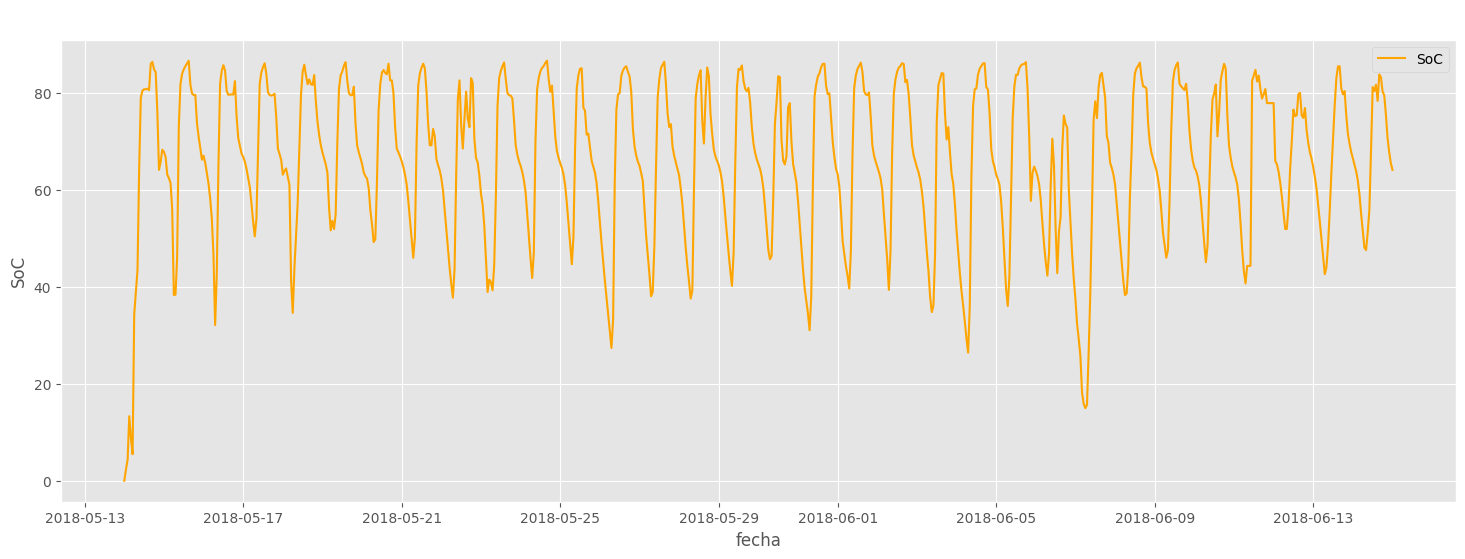

In [37]:
plt.style.use("ggplot")
plt.figure(figsize=(18,6))
plt.plot(test_dataset["battery"], color="orange", label="SoC")
plt.title(" ", fontsize=20)
plt.xlabel("fecha")
plt.ylabel("SoC")
plt.legend()
plt.show()

In [38]:
# Seleccionar la variable 'battery' para el modelo autoregresivo
#battery_data = train_dataset['battery']
#battery_data2 = test_dataset["battery"]

In [39]:
train_dataset2 = train_dataset[0:2500]
train_size = int(len(train_dataset) * 0.7)
train_data = train_dataset['battery'][:train_size]
test_data = train_dataset['battery'][train_size:]

In [40]:
train_data = train_data.asfreq("h")

In [41]:
train_data.head()

fecha
2018-05-06 00:00:00    72.690000
2018-05-06 01:00:00    69.382500
2018-05-06 02:00:00    66.723333
2018-05-06 03:00:00    63.733333
2018-05-06 04:00:00    61.465000
Freq: h, Name: battery, dtype: float64

In [42]:
# Aplicar el modelo AutoReg
train_data = train_data.asfreq("h")
lag = 72  # Ajusta según tu necesidad, en este caso estamos usando 3 para ilustrar
model = AutoReg(train_data, lags=lag)
model_fit = model.fit()

In [43]:
# Realizar predicciones para los próximos 3 pasos (esto puede ajustarse)
forecast_steps = len(test_data)
forecast = model_fit.predict(start=len(train_data), end=len(train_data) + 72)

In [44]:
# Evaluar las predicciones: Calcular MAE y RMSE
mae = mean_absolute_error(test_data[0:73], forecast)
rmse = np.sqrt(mean_squared_error(test_data[0:73], forecast))

In [45]:
# Imprimir las métricas
print(f"MAE (Error Absoluto Medio): {mae}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse}")

MAE (Error Absoluto Medio): 3.4202201423327394
RMSE (Raíz del Error Cuadrático Medio): 4.881747995199543


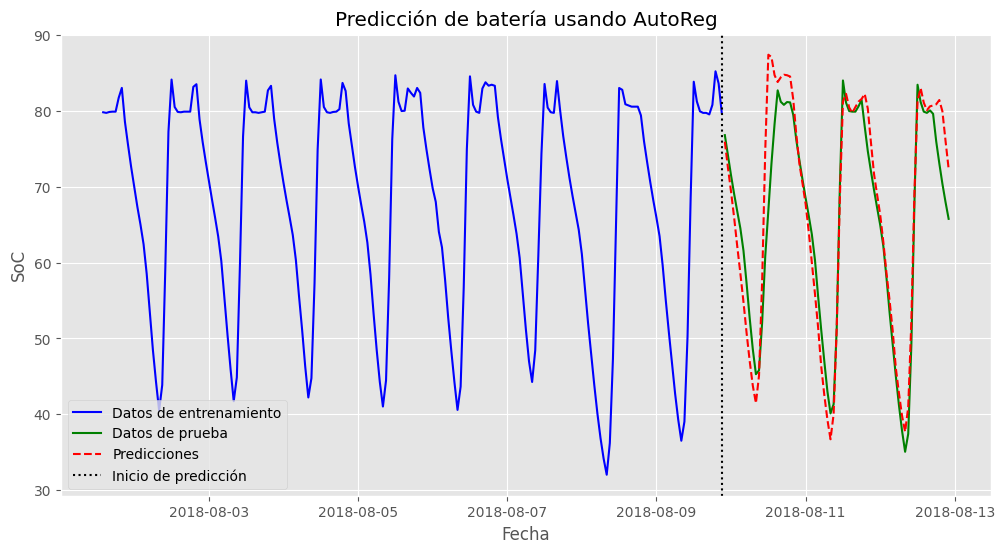

In [46]:
# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(train_data.index[-200:], train_data[-200:], label="Datos de entrenamiento", color='blue')
plt.plot(test_data.index[0:73], test_data[0:73], label="Datos de prueba", color='green')
plt.plot(test_data.index[0:73], forecast, label="Predicciones", color='red', linestyle='--')
plt.axvline(train_data.index[-1], color='black', linestyle=':', label="Inicio de predicción")
plt.title("Predicción de batería usando AutoReg")
plt.xlabel("Fecha")
plt.ylabel("SoC")
plt.legend()
plt.grid(True)
plt.savefig("Autoreg_train.png", dpi=300, bbox_inches='tight')
plt.show()

### Datos de TEST no conocidos

In [47]:
test_dataset2 = test_dataset["battery"]
train_size = int(len(test_dataset2) * 0.7)
train_data = test_dataset2[:train_size]
test_data = test_dataset2[train_size:]

In [48]:
# Realizar predicciones
forecast_steps = len(test_data)
forecast = model_fit.predict(start=len(train_data), end=len(train_data) + 72)

In [49]:
# Evaluar las predicciones: Calcular MAE y RMSE
mae = mean_absolute_error(test_data[0:73], forecast)
rmse = np.sqrt(mean_squared_error(test_data[0:73], forecast))

In [50]:
# Imprimir las métricas
print(f"MAE (Error Absoluto Medio): {mae}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse}")

MAE (Error Absoluto Medio): 11.47448541659207
RMSE (Raíz del Error Cuadrático Medio): 15.04824376832916


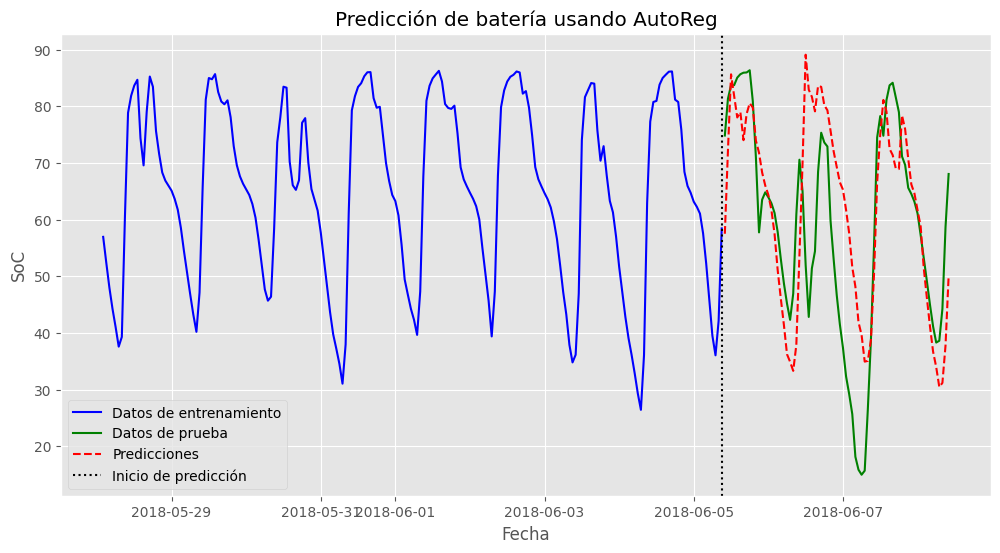

In [51]:
# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(train_data.index[-200:], train_data[-200:], label="Datos de entrenamiento", color='blue')
plt.plot(test_data.index[0:73], test_data[0:73], label="Datos de prueba", color='green')
plt.plot(test_data.index[0:73], forecast, label="Predicciones", color='red', linestyle='--')
plt.axvline(train_data.index[-1], color='black', linestyle=':', label="Inicio de predicción")
plt.title("Predicción de batería usando AutoReg")
plt.xlabel("Fecha")
plt.ylabel("SoC")
plt.legend()
plt.grid(True)
plt.savefig("Autoreg_test.png", dpi=300, bbox_inches='tight')
plt.show()

#### SARIMAX

In [52]:
train_dataset.head()

,temperature,pressure,battery,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,,
2018-05-06 00:00:00,15.056667,991.876667,72.690000,57.913333,0.0000,0.0,848.0,0
2018-05-06 01:00:00,12.505000,991.825000,69.382500,61.760000,0.6025,0.0,848.0,1
2018-05-06 02:00:00,11.056667,991.530000,66.723333,63.773333,0.0000,0.0,848.0,2
2018-05-06 03:00:00,10.866667,991.260000,63.733333,66.053333,0.0000,0.0,848.0,3
2018-05-06 04:00:00,12.347500,991.062500,61.465000,66.192500,0.6025,0.0,848.0,4


In [53]:
# Dividir los datos en entrenamiento y prueba (70% entrenamiento, 30% prueba)
train_size = int(len(train_dataset) * 0.7)
train_data = train_dataset['battery'][:train_size]
test_data = train_dataset['battery'][train_size:]

In [54]:
# Establecer las variables exógenas
exog_train = train_dataset[['temperature', 'pressure', 'air_humidity', 'wind_speed', 'irradiancia', "minutos_dia", "hora"]][:train_size]
exog_test = train_dataset[['temperature', 'pressure', 'air_humidity', 'wind_speed', 'irradiancia', "minutos_dia", "hora"]][train_size:]

In [55]:
exog_train = exog_train.asfreq("h")

In [56]:
# Definir y entrenar el modelo SARIMAX
# p, d, q son los parámetros del modelo ARIMA
# P, D, Q, S son los parámetros estacionales
SARIMAX_model = SARIMAX(train_data, exog=exog_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 24))
model_fit = SARIMAX_model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           12     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.00711D+00    |proj g|=  4.85858D-01


 This problem is unconstrained.



At iterate    5    f=  1.98835D+00    |proj g|=  3.06694D+00

At iterate   10    f=  1.95950D+00    |proj g|=  2.58681D-01

At iterate   15    f=  1.95234D+00    |proj g|=  1.07798D+00

At iterate   20    f=  1.95085D+00    |proj g|=  3.25050D-01

At iterate   25    f=  1.94065D+00    |proj g|=  4.65467D-01

At iterate   30    f=  1.93561D+00    |proj g|=  5.58066D-01

At iterate   35    f=  1.92716D+00    |proj g|=  1.27700D-02

At iterate   40    f=  1.92698D+00    |proj g|=  1.81922D-01

At iterate   45    f=  1.92660D+00    |proj g|=  2.40614D-02

At iterate   50    f=  1.92451D+00    |proj g|=  5.93584D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

/home/felipe/.local/share/virtualenvs/CodificandoBits-45IlOpmv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [57]:
# Realizar predicciones sobre los datos de prueba
forecast = model_fit.predict(start=len(train_data), end=len(train_data) + 72, exog=exog_test[0:73])

In [58]:
# Evaluar las predicciones: Calcular MAE y RMSE
mae = mean_absolute_error(test_data[0:73], forecast)
rmse = np.sqrt(mean_squared_error(test_data[0:73], forecast))

# Imprimir las métricas
print(f"MAE (Error Absoluto Medio): {mae}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse}")

MAE (Error Absoluto Medio): 6.396023040463877
RMSE (Raíz del Error Cuadrático Medio): 7.891779939248433


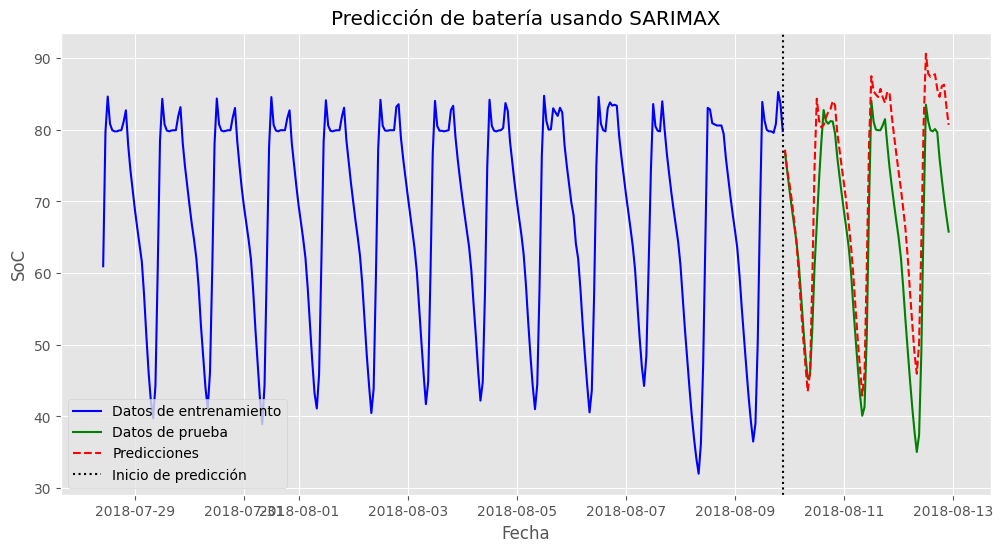

In [59]:
# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(train_data.index[-300:], train_data[-300:], label="Datos de entrenamiento", color='blue')
plt.plot(test_data.index[0:73], test_data[0:73], label="Datos de prueba", color='green')
plt.plot(test_data.index[0:73], forecast, label="Predicciones", color='red', linestyle='--')
plt.axvline(train_data.index[-1], color='black', linestyle=':', label="Inicio de predicción")
plt.title("Predicción de batería usando SARIMAX")
plt.xlabel("Fecha")
plt.ylabel("SoC")
plt.legend()
plt.grid(True)
plt.savefig("SARIMAX_train.png", dpi=300, bbox_inches='tight')
plt.show()

In [60]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            battery   No. Observations:                 2302
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood               -4430.216
Date:                            Fri, 20 Dec 2024   AIC                           8884.432
Time:                                    13:45:39   BIC                           8953.199
Sample:                                05-06-2018   HQIC                          8909.516
                                     - 08-09-2018                                         
Covariance Type:                              opg                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
temperature      0.1697      0.026      6.644      0.000       0.120       0.220
pressure        -0.2851      0.123     -2.317      0.021      -0.526      -0.044
air_humidity    -0.0556      0.010     -5.679      0.000      -0.075      -0.036
wind_speed       0.0464      0.016      2.881      0.004       0.015       0.078
irradiancia     -0.0022      0.001     -3.983      0.000      -0.003      -0.001
minutos_dia     -0.1927      0.591     -0.326      0.744      -1.351       0.966
hora          1.006e-07   5.56e-07      0.181      0.857    -9.9e-07    1.19e-06
ar.L1           -0.2108      0.030     -7.122      0.000      -0.269      -0.153
ma.L1            0.6242      0.029     21.421      0.000       0.567       0.681
ar.S.L24         0.1655      0.012     14.070      0.000       0.142       0.189
ma.S.L24        -0.9056      0.009   -102.793      0.000      -0.923      -0.888
sigma2           2.7186      0.040     68.253      0.000       2.641       2.797
===================================================================================
Ljung-Box (L1) (Q):                   1.57   Jarque-Bera (JB):             16500.28
Prob(Q):                              0.21   Prob(JB):                         0.00
Heteroskedasticity (H):               0.38   Skew:                             0.66
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.6e+20. Standard errors may be unstable.
"""

### A los datos normalizados le aplicamos PCA n = 5 componentes

In [61]:
X_train_norm.head()

,temperature,pressure,air_humidity,wind_speed,irradiancia,minutos_dia,hora
fecha,,,,,,,
2018-05-06 00:00:00,0.200275,0.574522,0.631946,0.000000,0.0,0.658683,0.000000
2018-05-06 01:00:00,0.135587,0.571512,0.696105,0.062435,0.0,0.658683,0.043478
2018-05-06 02:00:00,0.098870,0.554326,0.729686,0.000000,0.0,0.658683,0.086957
2018-05-06 03:00:00,0.094053,0.538596,0.767715,0.000000,0.0,0.658683,0.130435
2018-05-06 04:00:00,0.131594,0.527090,0.770036,0.062435,0.0,0.658683,0.173913


In [62]:
 # Aplicar PCA
pca = PCA(n_components=5)
data_pca = pca.fit_transform(X_train_norm)
explained_variance = pca.explained_variance_ratio_
print("Varianza explicada por cada componente principal:", explained_variance)

Varianza explicada por cada componente principal: [0.4720136  0.18670963 0.1678855  0.07369641 0.05043464]


In [63]:
df_pca = pd.DataFrame(data=data_pca, index=X_train_norm.index, columns=["PC1","PC2","PC3","PC4", "PC5"])

In [64]:
df_pca.head()

,PC1,PC2,PC3,PC4,PC5
fecha,,,,,
2018-05-06 00:00:00,0.599346,-0.213078,0.088184,0.219658,0.224447
2018-05-06 01:00:00,0.614169,-0.173209,0.090397,0.218767,0.160553
2018-05-06 02:00:00,0.664017,-0.148296,0.096619,0.149766,0.146631
2018-05-06 03:00:00,0.672620,-0.116527,0.095019,0.117967,0.111556
2018-05-06 04:00:00,0.613819,-0.077690,0.087096,0.130615,0.078591


In [65]:
train_data.head()

fecha
2018-05-06 00:00:00    72.690000
2018-05-06 01:00:00    69.382500
2018-05-06 02:00:00    66.723333
2018-05-06 03:00:00    63.733333
2018-05-06 04:00:00    61.465000
Name: battery, dtype: float64

In [66]:
df_pca.shape, train_data.shape

((3289, 5), (2302,))

In [67]:
SARIMAX_model = SARIMAX(train_data, exog=df_pca[0:2302], order=(1, 1, 1), seasonal_order=(1, 1, 1, 24))
model_fit = SARIMAX_model.fit()

/home/felipe/.local/share/virtualenvs/CodificandoBits-45IlOpmv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/home/felipe/.local/share/virtualenvs/CodificandoBits-45IlOpmv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           10     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.00707D+00    |proj g|=  1.46057D-01

At iterate    5    f=  1.93264D+00    |proj g|=  2.68331D-02

At iterate   10    f=  1.92472D+00    |proj g|=  4.85461D-03

At iterate   15    f=  1.92430D+00    |proj g|=  4.43327D-03

At iterate   20    f=  1.92322D+00    |proj g|=  5.67467D-03

At iterate   25    f=  1.92318D+00    |proj g|=  2.09439D-03

At iterate   30    f=  1.92316D+00    |proj g|=  1.73736D-04

At iterate   35    f=  1.92315D+00    |proj g|=  5.15782D-04

At iterate   40    f=  1.92313D+00    |proj g|=  1.01243D-04

At iterate   45    f=  1.92313D+00    |proj g|=  2.08397D-04


/home/felipe/.local/share/virtualenvs/CodificandoBits-45IlOpmv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



At iterate   50    f=  1.92311D+00    |proj g|=  1.66721D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   10     50     58      1     0     0   1.667D-03   1.923D+00
  F =   1.9231110968442098     

STOP: TOTAL NO. of ITERATIONS REACHED LIMIT                 


In [68]:
# Realizar predicciones sobre los datos de prueba
forecast = model_fit.predict(start=len(train_data), end=len(train_data) + 72, exog=df_pca[0:73])

In [69]:
# Evaluar las predicciones: Calcular MAE y RMSE
mae = mean_absolute_error(test_data[0:73], forecast)
rmse = np.sqrt(mean_squared_error(test_data[0:73], forecast))

# Imprimir las métricas
print(f"MAE (Error Absoluto Medio): {mae}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse}")

MAE (Error Absoluto Medio): 14.765187218104938
RMSE (Raíz del Error Cuadrático Medio): 19.784893902982816


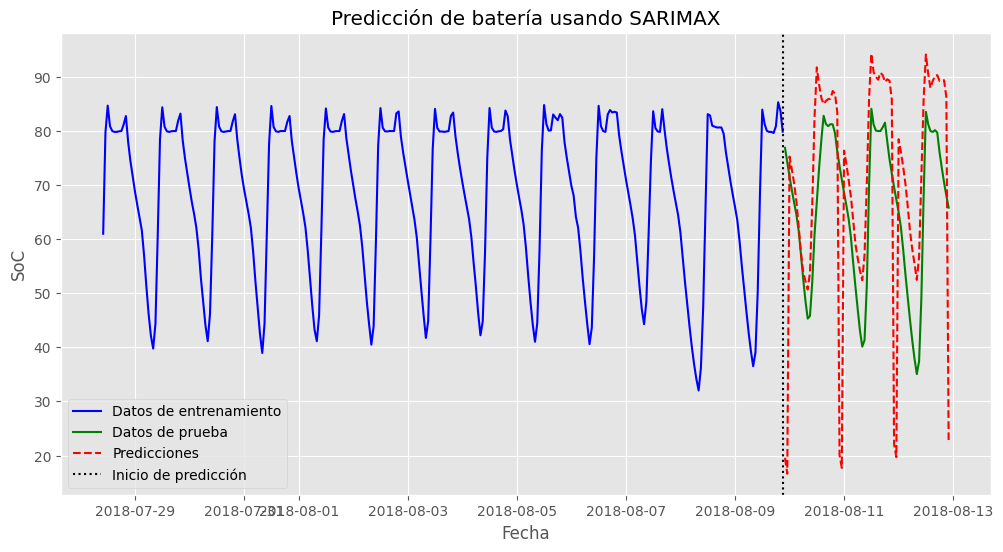

In [70]:
# Graficar los resultados
plt.figure(figsize=(12, 6))
plt.plot(train_data.index[-300:], train_data[-300:], label="Datos de entrenamiento", color='blue')
plt.plot(test_data.index[0:73], test_data[0:73], label="Datos de prueba", color='green')
plt.plot(test_data.index[0:73], forecast, label="Predicciones", color='red', linestyle='--')
plt.axvline(train_data.index[-1], color='black', linestyle=':', label="Inicio de predicción")
plt.title("Predicción de batería usando SARIMAX")
plt.xlabel("Fecha")
plt.ylabel("SoC")
plt.legend()
plt.grid(True)
plt.savefig("SARIMAX_train.png", dpi=300, bbox_inches='tight')
plt.show()

In [71]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            battery   No. Observations:                 2302
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood               -4427.002
Date:                            Fri, 20 Dec 2024   AIC                           8874.003
Time:                                    13:48:04   BIC                           8931.310
Sample:                                05-06-2018   HQIC                          8894.907
                                     - 08-09-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PC1          -21.5065      2.410     -8.923      0.000     -26.231     -16.783
PC2           44.8399      5.450      8.228      0.000      34.159      55.521
PC3           -8.8080      4.594     -1.917      0.055     -17.813       0.197
PC4          -30.9355      4.202     -7.362      0.000     -39.171     -22.700
PC5           -6.6401      1.991     -3.335      0.001     -10.543      -2.737
ar.L1         -0.1946      0.032     -6.008      0.000      -0.258      -0.131
ma.L1          0.5985      0.032     18.520      0.000       0.535       0.662
ar.S.L24       0.1887      0.012     15.802      0.000       0.165       0.212
ma.S.L24      -0.9348      0.008   -115.100      0.000      -0.951      -0.919
sigma2         2.8060      0.043     65.258      0.000       2.722       2.890
===================================================================================
Ljung-Box (L1) (Q):                   0.60   Jarque-Bera (JB):             16871.61
Prob(Q):                              0.44   Prob(JB):                         0.00
Heteroskedasticity (H):               0.38   Skew:                             0.69
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [72]:
import os
# Guardar el modelo SARIMAX en disco
model_fit.save('sarimax_model.pkl')